# Dataset Quality and EDA: SaaS Sales Conversations

A Exploratory Data Analysis tailored to uncover critical data constraints, assess data leakage risks, and identify underlying biases prior to modeling.

In [2]:
# 1. Load data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datasets import load_dataset
import warnings
warnings.filterwarnings('ignore')

# Login using e.g. `huggingface-cli login` to access this dataset
ds = load_dataset("DeepMostInnovations/saas-sales-conversations")
df = ds['train'].to_pandas().sample(n=8000, random_state=42)

df.head()

,company_id,company_name,product_name,product_type,conversation_id,scenario,conversation,full_text,outcome,conversation_length,...,embedding_3062,embedding_3063,embedding_3064,embedding_3065,embedding_3066,embedding_3067,embedding_3068,embedding_3069,embedding_3070,embedding_3071
75721,saas-15,EcoDesktop Solutions,EcoVirtual Desktop,Sustainable Development,saas-15-conv-668,"{""customer_persona"": {""name"": ""Jessica Thompso...","[{""speaker"": ""customer"", ""message"": ""Hey, um, ...","Hey, um, is this EcoDesktop? Yep! You got it, ...",1,12,...,-0.003219,-0.009239,0.005757,-0.002920,0.002924,0.001601,0.005275,-0.007489,-0.008292,-0.016341
80184,saas-19,RetailTech Solutions,GameStore Pro,Gaming,saas-19-conv-206,"{""customer_persona"": {""name"": ""Michael Anderso...","[{""speaker"": ""customer"", ""message"": ""Hey, um, ...","Hey, um, this is Michael from Gamer's Haven......",1,11,...,0.003455,0.003534,0.002329,-0.000921,-0.003691,-0.015912,0.024195,0.001248,0.000966,-0.012309
19864,saas-12,LLM Innovate,SmartLLM Platform,Technology,saas-12-conv-4849,"{""customer_persona"": {""name"": ""Jordan Smith"", ...","[{""speaker"": ""customer"", ""message"": ""Hey, um, ...","Hey, um, I was looking into, like, ways to imp...",1,10,...,0.007657,0.002178,-0.008312,0.014114,0.011612,-0.019253,0.006119,0.011604,-0.002248,-0.009068
76699,saas-15,EcoDesktop Solutions,EcoVirtual Desktop,Sustainable Development,saas-15-conv-1754,"{""customer_persona"": {""name"": ""Linda Thompson""...","[{""speaker"": ""customer"", ""message"": ""Hey, I wa...","Hey, I was lookin into options for virtual des...",0,13,...,0.008437,0.004808,-0.000590,0.006494,0.011653,0.002664,-0.001236,-0.002786,0.005692,-0.009787
92991,saas-18,LogiMarketer,AutoLogistics Pro,Logistics,saas-18-conv-2937,"{""customer_persona"": {""name"": ""Emily Johnson"",...","[{""speaker"": ""customer"", ""message"": ""So, um, t...","So, um, thanks for meeting with me. I've been,...",1,9,...,0.010677,-0.004995,0.013133,-0.018622,-0.005288,-0.016032,0.017130,0.006143,-0.005623,-0.028008


In [3]:
# 2. Basic info
print("Shape:", df.shape)
print("\n--- Info ---")
df.info()
print("\n--- Describe ---")
df.describe()

Shape: (8000, 3088)

--- Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 8000 entries, 75721 to 24896
Columns: 3088 entries, company_id to embedding_3071
dtypes: float64(3074), int64(2), object(12)
memory usage: 188.5+ MB

--- Describe ---


,outcome,conversation_length,customer_engagement,sales_effectiveness,embedding_0,embedding_1,embedding_2,embedding_3,embedding_4,embedding_5,...,embedding_3062,embedding_3063,embedding_3064,embedding_3065,embedding_3066,embedding_3067,embedding_3068,embedding_3069,embedding_3070,embedding_3071
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,...,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,0.497500,11.952125,0.642477,0.611716,-0.026910,0.001421,-0.019208,-0.003824,-0.004854,-0.016868,...,0.004174,-0.003769,0.003940,0.004190,0.010117,-0.016088,0.014502,0.001397,-0.001451,-0.013207
std,0.500025,1.518510,0.116907,0.157771,0.012054,0.015380,0.004336,0.012473,0.016355,0.014085,...,0.007875,0.006949,0.010024,0.008884,0.008426,0.010271,0.007010,0.006716,0.007987,0.008708
min,0.000000,8.000000,0.300000,0.300000,-0.069766,-0.060625,-0.038609,-0.058817,-0.051781,-0.062554,...,-0.019890,-0.028300,-0.031599,-0.027473,-0.021402,-0.051229,-0.008429,-0.024538,-0.034285,-0.043653
25%,0.000000,11.000000,0.600000,0.500000,-0.034855,-0.007552,-0.022092,-0.012195,-0.016058,-0.026520,...,-0.001316,-0.008654,-0.003164,-0.001689,0.004822,-0.022742,0.009526,-0.003254,-0.006455,-0.019389
50%,0.000000,12.000000,0.700000,0.600000,-0.027151,0.002399,-0.019102,-0.002801,-0.006709,-0.016789,...,0.003817,-0.003942,0.004871,0.004221,0.010343,-0.016421,0.014406,0.001282,-0.001057,-0.013626
75%,1.000000,13.000000,0.700000,0.750000,-0.019182,0.012221,-0.016277,0.005144,0.004345,-0.007076,...,0.009444,0.000951,0.011450,0.010242,0.015723,-0.009478,0.019512,0.005935,0.003971,-0.007325
max,1.000000,18.000000,0.900000,0.900000,0.018791,0.045446,-0.003648,0.036959,0.056911,0.028577,...,0.031192,0.021326,0.030651,0.031756,0.039636,0.019204,0.039474,0.025173,0.026636,0.017484


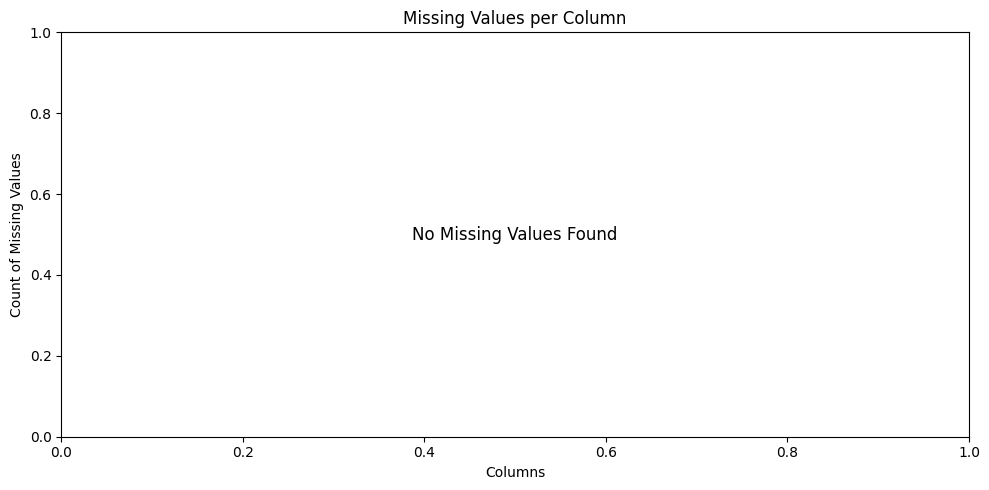

In [4]:
# 3. Missing values

missing = df.isnull().sum()

# Keep only columns with missing values
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 5))

if len(missing) > 0:
    sns.barplot(
        x=missing.index,
        y=missing.values
    )

    plt.xticks(rotation=45, ha='right')
else:
    plt.text(0.5, 0.5, "No Missing Values Found",
             ha='center', va='center', fontsize=12)

plt.title("Missing Values per Column")
plt.xlabel("Columns")
plt.ylabel("Count of Missing Values")
plt.tight_layout()
plt.show()

In [5]:
# 4. Data cleaning
# Simply impute missing values (mean for numerical, mode for categorical)
for col in df.columns:
    if df[col].dtype in ['float64', 'int64']:
        df[col] = df[col].fillna(df[col].mean())
    else:
        # Safe mode extraction for categorical/object
        modes = df[col].mode()
        if not modes.empty:
            df[col] = df[col].fillna(modes[0])

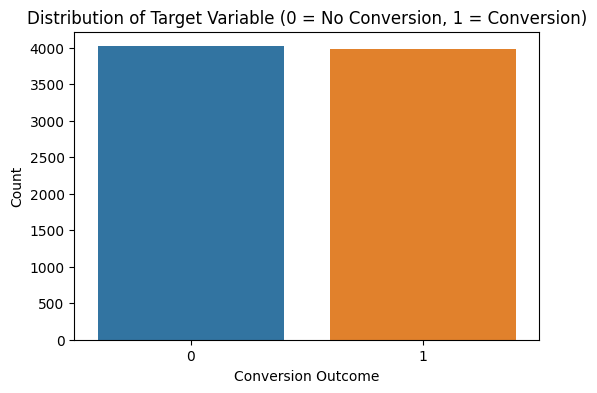

In [6]:
# 5. Target variable
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="outcome", hue="outcome", legend=False)
plt.title("Distribution of Target Variable (0 = No Conversion, 1 = Conversion)")
plt.xlabel("Conversion Outcome")
plt.ylabel("Count")
plt.show()

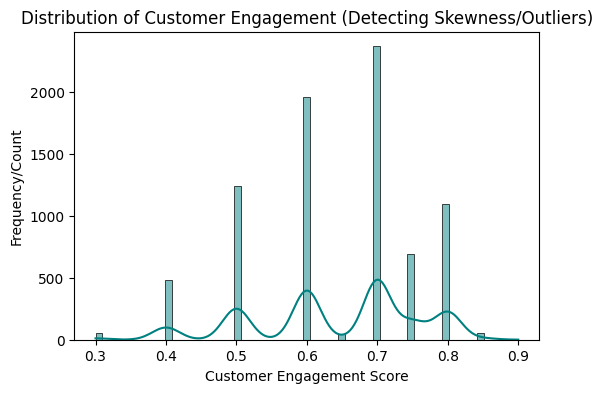

In [7]:
# 6. Numerical features: Distribution (Customer Engagement)
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x="customer_engagement", kde=True, color="teal")
plt.title("Distribution of Customer Engagement (Detecting Skewness/Outliers)")
plt.xlabel("Customer Engagement Score")
plt.ylabel("Frequency/Count")
plt.show()

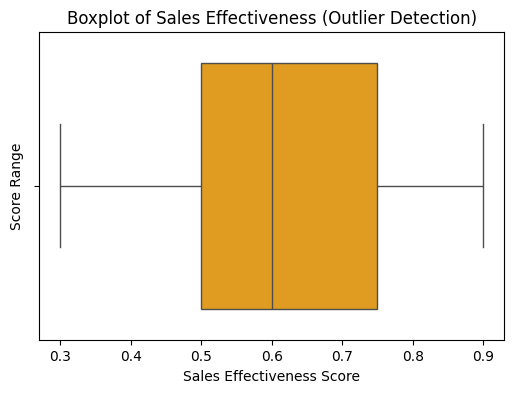

In [8]:
# 6. Numerical features: Boxplot (Sales Effectiveness)
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="sales_effectiveness", color="orange")
plt.title("Boxplot of Sales Effectiveness (Outlier Detection)")
plt.xlabel("Sales Effectiveness Score")
plt.ylabel("Score Range")
plt.show()

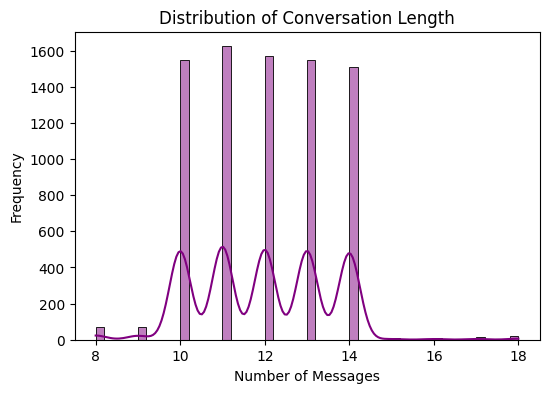

In [9]:
# 6. Numerical features: Distribution (Conversation Length)
if 'conversation_length' in df.columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df, x="conversation_length", kde=True, color="purple")
    plt.title("Distribution of Conversation Length")
    plt.xlabel("Number of Messages")
    plt.ylabel("Frequency")
    plt.show()

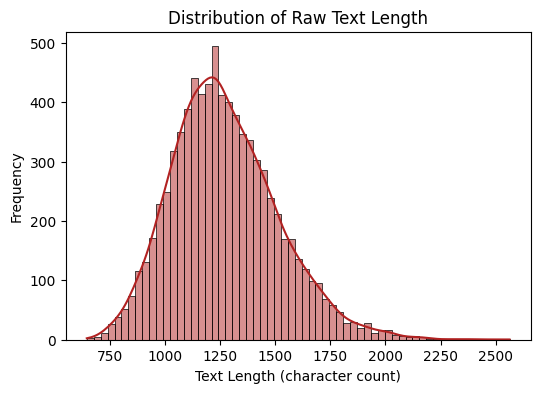

In [10]:
# 7. Text feature mapping: Create text length
df['text_length'] = df['full_text'].astype(str).str.len()

plt.figure(figsize=(6, 4))
sns.histplot(data=df, x="text_length", kde=True, color="firebrick")
plt.title("Distribution of Raw Text Length")
plt.xlabel("Text Length (character count)")
plt.ylabel("Frequency")
plt.show()

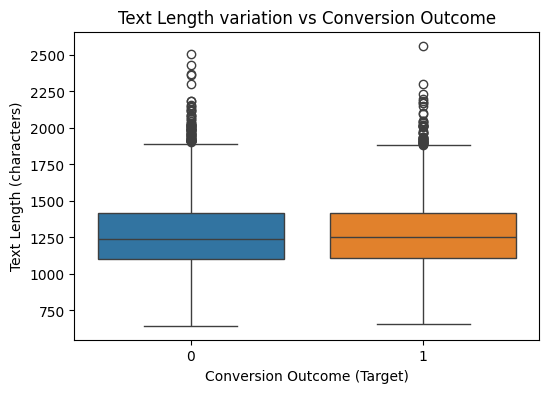

In [11]:
# 7. Text feature: Text Length vs Target
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="outcome", y="text_length", hue="outcome", legend=False)
plt.title("Text Length variation vs Conversion Outcome")
plt.xlabel("Conversion Outcome (Target)")
plt.ylabel("Text Length (characters)")
plt.show()

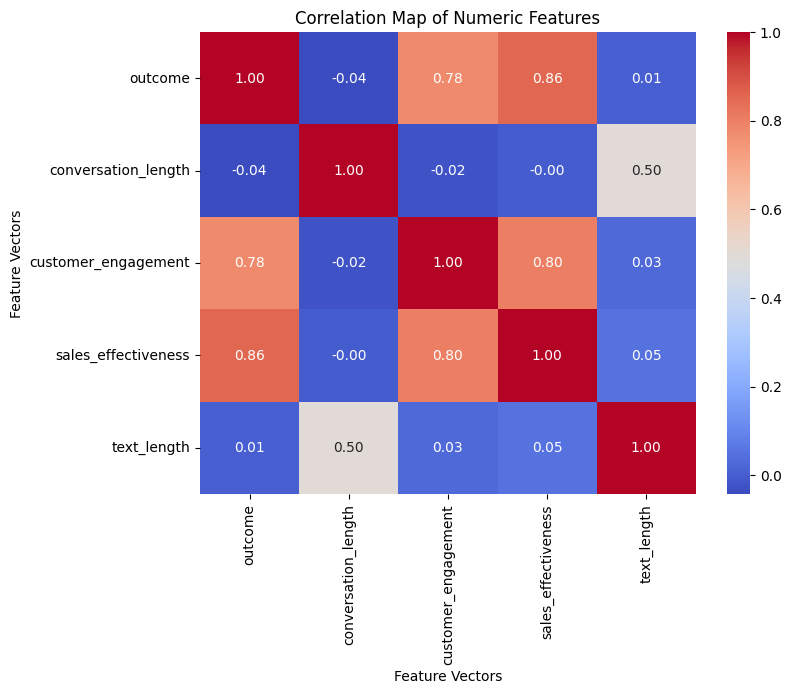

In [12]:
# 8. Correlation Heatmap
plt.figure(figsize=(8, 6))
numeric_cols = df.select_dtypes(include=['number']).columns
# Exclude structural embedding columns if present to focus on raw features
simple_num = [c for c in numeric_cols if not c.startswith('embedding_')]

sns.heatmap(df[simple_num].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Map of Numeric Features")
plt.xlabel("Feature Vectors")
plt.ylabel("Feature Vectors")
plt.show()

In [13]:
# 9. Hidden nuances (Leakage risks, Imbalance, Biases)
print("---- Hidden Feature Nuances ----\n")

# A. Check duplicate rows indicating synthetic anomaly or dataset contamination
print(f"1. Exact duplicate rows encountered: {df.duplicated().sum()}\n")

# B. Check data leakage risks (Direct predictability & extremely high correlation)
corr_outcome = df[simple_num].corr()['outcome'].drop('outcome', errors='ignore').abs()
leak_suspects = corr_outcome[corr_outcome > 0.70]
print(f"2. Potential Data Leakage Risk:\n{leak_suspects if not leak_suspects.empty else 'No >0.70 correlation identified.'}\n")

# C. Dataset Bias (Category checking for imbalance)
if 'product_type' in df.columns:
    bias = df.groupby('product_type')['outcome'].agg(['mean', 'count'])
    print("3. Bias/Imbalance Check (Conversion Rate by Product Type):\n", bias)

---- Hidden Feature Nuances ----

1. Exact duplicate rows encountered: 0

2. Potential Data Leakage Risk:
customer_engagement    0.778691
sales_effectiveness    0.856921
Name: outcome, dtype: float64

3. Bias/Imbalance Check (Conversion Rate by Product Type):
                              mean  count
product_type                            
Biotechnology            0.509333    375
Cloud Services           0.510000    800
Data Science             0.493088    434
Gaming                   0.539759    415
Healthcare               0.522613    398
Logistics                0.496053    760
Marketing Services       0.497436    390
Non-profit               0.468750    416
Professional Services    0.439206    403
Renewable Energy         0.483645    428
Retail                   0.483544    395
Smart Cities             0.474642    769
Staffing                 0.517241    812
Sustainable Development  0.503778    794
Technology               0.508516    411


### Final Conclusion & Modeling Strategy

Based on the EDA, the following critical themes shape our modeling decisions:

1. **Class Balance Observation:** The target variable (`outcome`) is **well-balanced**, with approximately 49.75% conversions (class 1 ≈ 3,980) and 50.25% non-conversions (class 0 ≈ 4,020) out of 8,000 samples. Standard accuracy is a valid baseline metric here. **Implementation Decision:** Class rebalancing techniques like SMOTE or class-weight adjustments are **not required**. Standard metrics — Accuracy, F1 score, and ROC-AUC — can all be used reliably.
2. **Skewed Features:** Variables such as `customer_engagement` and `text_length` do not follow a perfect normal distribution (exhibiting skewness or heavy tails). **Implementation Decision:** Tree-based models (e.g., Random Forests, Gradient Boosting) will natively handle these shapes without strict normalization requirements. Normalization remains an option for linear architectures if needed.
3. **Importance of Text Data:** Longer text inputs show correlation with successful conversions, but raw length is only a surface-level signal. **Implementation Decision:** NLP modeling over `full_text` (e.g., TF-IDF, embeddings, or transformers) should provide stronger discriminative power by capturing conversational intent beyond just length.
4. **Detected Risks (Leakage & Bias):**
    *   **Potential Data Leakage Risk:** Features like `customer_engagement` (r ≈ 0.78) and `sales_effectiveness` (r ≈ 0.86) exhibit very high correlations with `outcome`. If these scores were assigned post-outcome (i.e., retrospectively labelled), they act as "answer keys" and introduce leakage. Strict validation is required to confirm these are real-time predictive signals.
    *   **Dataset Bias:** Conversion rates vary modestly across `product_type` categories (ranging from ~44% for Professional Services to ~54% for Gaming). While no single category is severely underrepresented, proper stratified splitting during train/test division is recommended to ensure proportional representation across all product types.